## 1. Loading and parsing the raw CSV data

The project uses a `monthly.csv` file with historical monthly gold prices from the 19th to the 21st century.  
Each row contains a year-month date (YYYY-MM) and the corresponding gold price.

In this first step I:
- load the raw CSV file from disk,
- skip the header row,
- split each line into a date string and a price value,
- split the date into `year` and `month`,
- store all values in Python lists for further processing.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Path to the CSV file with monthly gold prices
filename = r"C:\Users\paw20\OneDrive\Desktop\monthly.csv"

# Read all lines from the CSV file
with open(filename, "r") as f:
    lines = f.readlines()

# Skip the header row
data_lines = lines[1:]

# Prepare Python lists for raw values
years = []
months = []
prices = []

for line in data_lines:
    line = line.strip()
    parts = line.split(",")
    date_str = parts[0]
    price_str = parts[1]

    # date is in the format YYYY-MM
    year_str, month_str = date_str.split("-")

    years.append(int(year_str))
    months.append(int(month_str))
    prices.append(float(price_str))

## 2. Converting to NumPy and computing yearly medians

After loading the raw lists, I convert them into NumPy arrays for easier numerical operations. 
Then I group the data by year and compute the median gold price for each year.

This gives me a time series of yearly median prices that smooths out monthly noise.  
I then plot this series to visualize long-term trends over the full historical period.

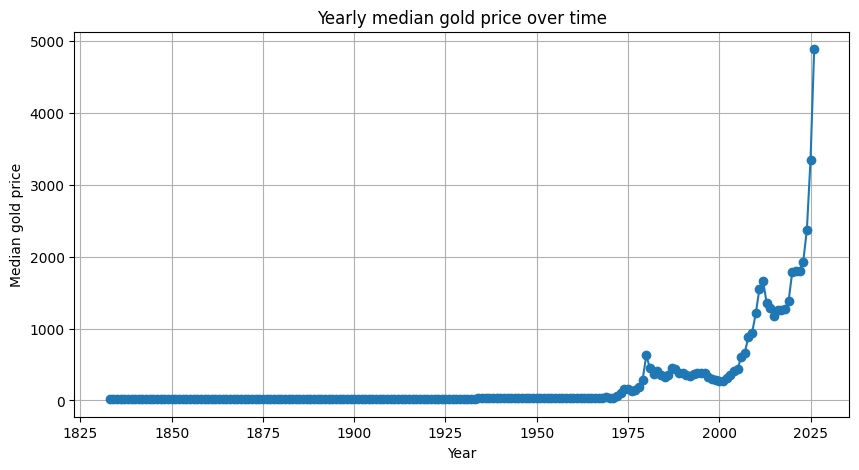

In [2]:
# Convert Python lists to NumPy arrays
np_years = np.array(years)
np_months = np.array(months)
np_prices = np.array(prices)

# Optional: combine into a single 2D array (year, month, price)
data = np.column_stack([np_years, np_months, np_prices])

# Compute yearly median prices
medians = []
unique_years = np.unique(np_years)

for year in unique_years:
    mask = (np_years == year)
    prices_this_year = np_prices[mask]
    median = np.median(prices_this_year)
    medians.append(float(median))

# Plot yearly median prices over time
plt.figure(figsize=(10, 5))
plt.plot(unique_years, medians, marker="o")
plt.xlabel("Year")
plt.ylabel("Median gold price")
plt.title("Yearly median gold price over time")
plt.grid(True)
plt.show()

## 3. Comparing median prices across centuries

To compare long-term levels, I split the data into three centuries:
- 19th century: 1801–1900,
- 20th century: 1901–2000,
- 21st century: 2001–2100 (practically up to the last available year in the dataset).
For each century, I compute the median gold price using all available monthly observations.  
Finally, I create a bar chart to compare the typical price level between centuries.

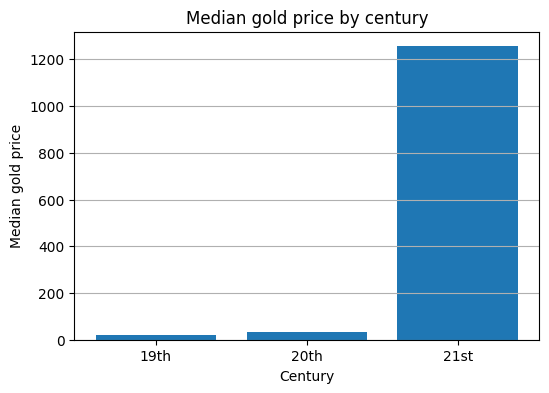

In [3]:
# Define boolean masks for each century
mask_19 = (np_years >= 1801) & (np_years <= 1900)
mask_20 = (np_years >= 1901) & (np_years <= 2000)
mask_21 = (np_years >= 2001) & (np_years <= 2100)

# Extract prices for each century
prices_19 = np_prices[mask_19]
prices_20 = np_prices[mask_20]
prices_21 = np_prices[mask_21]

# Compute median price per century
med_price_19 = np.median(prices_19)
med_price_20 = np.median(prices_20)
med_price_21 = np.median(prices_21)

labels = ["19th", "20th", "21st"]
medians_centuries = (med_price_19, med_price_20, med_price_21)

# Bar plot of median prices by century
plt.figure(figsize=(6, 4))
plt.bar(labels, medians_centuries)
plt.xlabel("Century")
plt.ylabel("Median gold price")
plt.title("Median gold price by century")
plt.grid(True, axis="y")
plt.show()

## 4. Zooming in on modern history (1970–2026)

Because the most dramatic changes in gold prices occur in the modern era, I zoom in on the period from 1970 onwards.
I filter the data to 1970–2026 and plot the raw monthly prices to see more detailed short- and medium-term movements.

This line plot highlights major spikes and structural changes in the gold market, which are less visible in the full-history view.

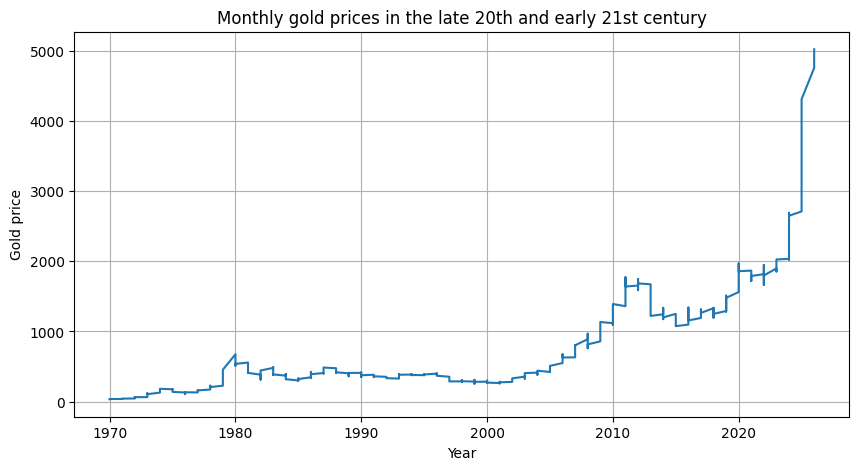

In [4]:
# Focus on the modern period: 1970–2026
mask_modern = (np_years >= 1970) & (np_years <= 2026)
modern_prices = np_prices[mask_modern]
modern_years = np_years[mask_modern]

# Line plot of monthly prices in the modern era
plt.figure(figsize=(10, 5))
plt.plot(modern_years, modern_prices)
plt.xlabel("Year")
plt.ylabel("Gold price")
plt.title("Monthly gold prices in the late 20th and early 21st century")
plt.grid(True)
plt.show()

## 5. Scatter plot of prices in the 21st century

Next, I focus exclusively on the 21st century to inspect how volatile prices are year by year. 
I filter the data to 2000–2026 and create a scatter plot with one point per monthly observation.

This visualization helps to see both the overall upward shift and the spread of values within each year.

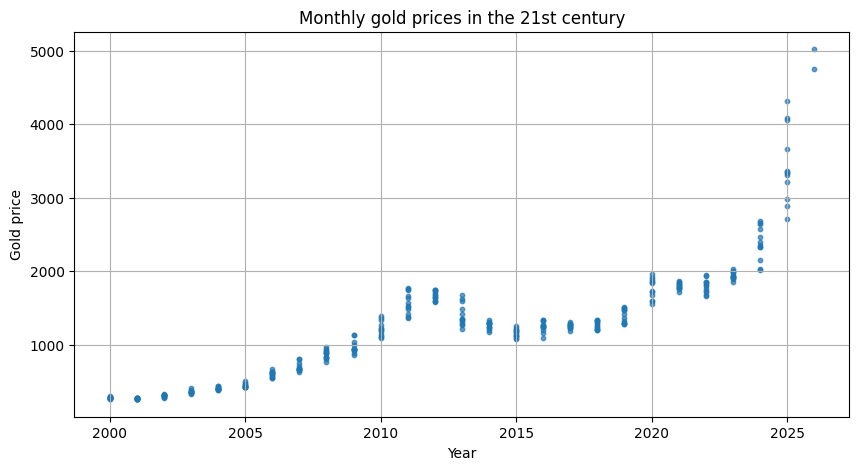

In [5]:
# Filter data for the 21st century: 2000–2026
mask_summary = (np_years >= 2000) & (np_years <= 2026)
price_summary = np_prices[mask_summary]
years_summary = np_years[mask_summary]

# Scatter plot of monthly prices in the 21st century
plt.figure(figsize=(10, 5))
plt.scatter(years_summary, price_summary, s=10, alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Gold price")
plt.title("Monthly gold prices in the 21st century")
plt.grid(True)
plt.show()

## 6. Seasonality: median price by month (2000–2026)

To check for seasonality, I look at how gold prices differ between calendar months in the 21st century. 
I filter the data to 2000–2026, then for each month (1–12) compute the median price across all years.

Finally, I plot these 12 median values as a bar chart, which reveals whether some months tend to have systematically higher or lower prices.

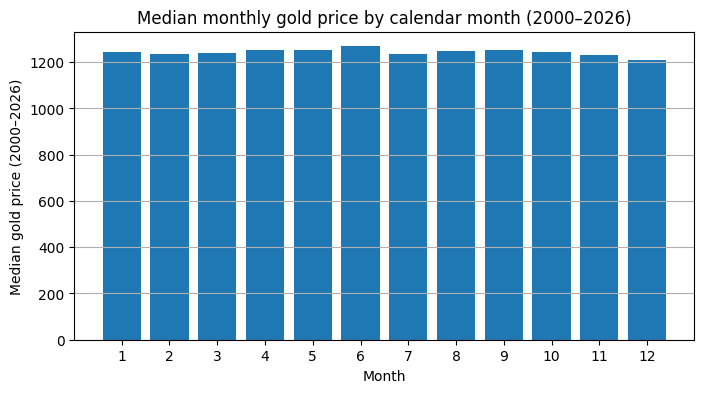

In [6]:
# Filter data for the 21st century (2000–2026)
chosen_mask = (np_years >= 2000) & (np_years <= 2026)
years_century = np_years[chosen_mask]
months_century = np_months[chosen_mask]
prices_century = np_prices[chosen_mask]

# Compute median price for each calendar month (1–12)
medians_by_month = []

for month in range(1, 13):
    month_mask = (months_century == month)
    month_prices = prices_century[month_mask]
    month_median = np.median(month_prices)
    medians_by_month.append(float(month_median))

months_list = list(range(1, 13))

# Bar plot of median price by month
plt.figure(figsize=(8, 4))
plt.bar(months_list, medians_by_month)
plt.xlabel("Month")
plt.ylabel("Median gold price (2000–2026)")
plt.title("Median monthly gold price by calendar month (2000–2026)")
plt.grid(axis="y")
plt.xticks(months_list)
plt.show()

## 7. Key insights and interpretation

### Long-term trends

Over the full historical period, the yearly median gold price remains relatively low and stable during the 19th century.
In the 20th and especially the 21st century, the median price increases sharply, indicating a strong long-term upward trend in gold prices.

### Differences between centuries

The 19th century shows the lowest median price level, with limited variation compared to later periods.
The 20th century already has a higher median, but the 21st century stands out with the highest typical price level, reflecting structural changes in the global economy and financial markets.

### Seasonality between months

When looking at 2000–2026, median prices by month show only modest differences between calendar months. 
There is no very strong, consistent seasonal pattern, although some months may have slightly higher or lower typical prices, suggesting that long-term trends dominate over simple month-of-year seasonality.